# GeneralRFM and Fisheye Coordinates

Use fisheye coordinates to place resolution where the physics needs it and inspect the generated support calls.

Navigation: [Index](../index.ipynb) | Previous: [Curvilinear Boundary Conditions](curvilinear_boundary_conditions.ipynb) | Next: [Multicoordinate Wave Project](../3-wave_equation/wave_equation_multicoordinates.ipynb)


## Learning Goals

- Understand fisheye coordinates as a way to place more grid points where they are useful.
- Sample the map between raw grid radius and physical radius.
- Check that generated support routines know the coordinate parameters.

## Words for This Notebook

- **Fisheye coordinates:** a smooth coordinate map that changes grid spacing with radius.
- **Raw radius:** the coordinate value used on the numerical grid.
- **Physical radius:** the radius interpreted as distance in the modeled space.
- **Transition:** the region where the map changes from one spacing behavior to another.

Use the code cells actively: first predict what should happen, then run the cell, then explain the output in plain language. This predict-run-explain pattern keeps the physics idea connected to the programming details.


## Fisheye Map and Metric Residuals
The sample values show how raw radius maps to a stretched radius. The residuals verify that the metric follows from the coordinate map.

## Step 1: Build the fisheye map and print its symbolic parameters

Build the fisheye map and print its symbolic parameters.

In [1]:
import sympy as sp

import nrpy.reference_metric as refmetric
from nrpy.equations.generalrfm import fisheye
from nrpy.infrastructures.BHaH import generalrfm_precompute
from nrpy.infrastructures.BHaH.fisheye import phys_params_to_fisheye

fisheye_map = fisheye.build_fisheye(2)
print("transitions:", fisheye_map.num_transitions)
print("raw coordinates:", fisheye_map.xx)
print("plateau factors:", fisheye_map.a_list)
print("transition centers:", fisheye_map.R_list)
print("transition widths:", fisheye_map.s_list)
print("scale factor:", fisheye_map.c)


transitions: 2
raw coordinates: [xx0, xx1, xx2]
plateau factors: [fisheye_a0, fisheye_a1, fisheye_a2]
transition centers: [fisheye_R1, fisheye_R2]
transition widths: [fisheye_s1, fisheye_s2]
scale factor: fisheye_c


## Step 2: Inspect the coordinate map and registered reference metric

Inspect the coordinate map and registered reference metric.

In [2]:
print("rbar_unscaled:", fisheye_map.rbar_unscaled)
print("xx_to_CartU:")
for component in fisheye_map.xx_to_CartU:
    print(component)
rfm = refmetric.reference_metric["GeneralRFM_fisheyeN2"]
print("reference metric:", rfm.CoordSystem)
print("provider:", rfm.general_rfm_provider_name)
print("provider metadata:", rfm.general_rfm_provider_meta)


rbar_unscaled: fisheye_a2*sqrt(xx0**2 + xx1**2 + xx2**2) + fisheye_s1*(fisheye_a0 - fisheye_a1)*log(cosh((fisheye_R1 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s1)/cosh((-fisheye_R1 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s1))/(2*tanh(fisheye_R1/fisheye_s1)) + fisheye_s2*(fisheye_a1 - fisheye_a2)*log(cosh((fisheye_R2 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s2)/cosh((-fisheye_R2 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s2))/(2*tanh(fisheye_R2/fisheye_s2))
xx_to_CartU:
fisheye_c*xx0*(fisheye_a2*sqrt(xx0**2 + xx1**2 + xx2**2) + fisheye_s1*(fisheye_a0 - fisheye_a1)*log(cosh((fisheye_R1 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s1)/cosh((-fisheye_R1 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s1))/(2*tanh(fisheye_R1/fisheye_s1)) + fisheye_s2*(fisheye_a1 - fisheye_a2)*log(cosh((fisheye_R2 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s2)/cosh((-fisheye_R2 + sqrt(xx0**2 + xx1**2 + xx2**2))/fisheye_s2))/(2*tanh(fisheye_R2/fisheye_s2)))/sqrt(xx0**2 + xx1**2 + xx2**2)
fisheye_c*xx1*(fisheye_a2*sqr

reference metric: GeneralRFM_fisheyeN2
provider: fisheye
provider metadata: {'num_transitions': 2}


## Step 3: Sample the raw-to-physical radius map

Sample the raw-to-physical radius map.

In [3]:
substitutions = {
    fisheye_map.a_list[0]: sp.Rational(1, 1),
    fisheye_map.a_list[1]: sp.Rational(3, 2),
    fisheye_map.a_list[2]: sp.Rational(2, 1),
    fisheye_map.R_list[0]: sp.Rational(1, 1),
    fisheye_map.R_list[1]: sp.Rational(3, 1),
    fisheye_map.s_list[0]: sp.Rational(2, 5),
    fisheye_map.s_list[1]: sp.Rational(7, 10),
    fisheye_map.c: sp.Rational(1, 1),
}
for raw_radius in [
    sp.Rational(1, 4),
    sp.Rational(1, 1),
    sp.Rational(2, 1),
    sp.Rational(4, 1),
]:
    value = fisheye_map.rbar_unscaled.subs(
        {
            fisheye_map.xx[0]: raw_radius,
            fisheye_map.xx[1]: 0,
            fisheye_map.xx[2]: 0,
            **substitutions,
        }
    )
    print(raw_radius, sp.N(value, 12))


1/4 0.250468824080


1 1.06385200044


2 2.50329428319


4 6.00242433075


## Plot the Fisheye Radius Map

The fisheye map changes how numerical grid radius corresponds to physical radius. A straight diagonal would mean no stretching; bends show where resolution is redistributed.

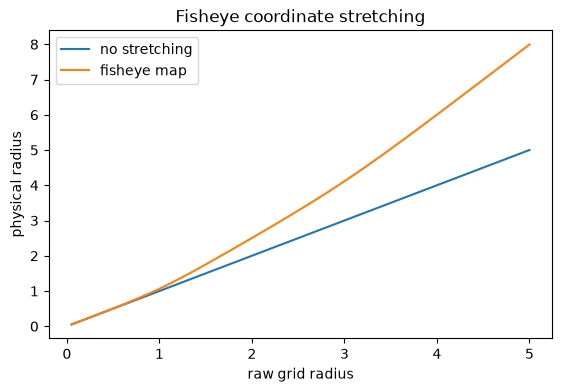

In [4]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
import numpy as np


radial_expr = fisheye_map.rbar_unscaled.subs(
    {
        fisheye_map.xx[1]: 0,
        fisheye_map.xx[2]: 0,
        **substitutions,
    }
)
radius_map = sp.lambdify(fisheye_map.xx[0], radial_expr, "numpy")
raw_samples = np.linspace(0.05, 5.0, 200)
physical_samples = radius_map(raw_samples)
plt.figure(figsize=(6.5, 4))
plt.plot(raw_samples, raw_samples, label="no stretching")
plt.plot(raw_samples, physical_samples, label="fisheye map")
plt.xlabel("raw grid radius")
plt.ylabel("physical radius")
plt.title("Fisheye coordinate stretching")
plt.legend()
plt.show()

## Step 4: Check selected metric residuals

Check selected metric residuals.

In [5]:
for i, j in [(0, 0), (0, 1), (1, 1), (2, 2)]:
    induced_metric_ij = sum(
        fisheye_map.dCart_dxxUD[k][i] * fisheye_map.dCart_dxxUD[k][j] for k in range(3)
    )
    residual = sp.simplify(fisheye_map.ghatDD[i][j] - induced_metric_ij)
    print(f"residual ({i}, {j}) =", residual)
    if residual != 0:
        raise RuntimeError("Expected the residual to vanish.")


residual (0, 0) = 0


residual (0, 1) = 0


residual (1, 1) = 0


residual (2, 2) = 0


## Step 5: List support hooks used by generated fisheye infrastructure

List support hooks used by generated fisheye infrastructure.

In [6]:
for label, function in [
    (
        "generalrfm_precompute",
        generalrfm_precompute.register_CFunction_generalrfm_precompute,
    ),
    (
        "generalrfm_support",
        generalrfm_precompute.register_CFunctions_generalrfm_support,
    ),
    (
        "fisheye_params_from_physical",
        phys_params_to_fisheye.register_CFunction_fisheye_params_from_physical_N,
    ),
    (
        "post_params_hook",
        phys_params_to_fisheye.build_post_params_struct_set_to_default_hook,
    ),
]:
    print(label, callable(function))


generalrfm_precompute True
generalrfm_support True
fisheye_params_from_physical True
post_params_hook True


The mapping output shows how GeneralRFM changes coordinate spacing while preserving the reference-metric machinery. Fisheye maps use this to concentrate resolution where the wave is most interesting.


## Learning Check

Before sampling the map, predict whether the raw and physical radius should always be equal. Use the printed samples to explain the answer.


## Continue to Multicoordinate Projects
- [Reference-Metric Applications](reference_metric_applications.ipynb)
- [Multicoordinate Wave Project](../3-wave_equation/wave_equation_multicoordinates.ipynb)
